In [74]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from cgmvae import*

In [75]:
# intialize config
latent_path = '/home/rachel/Desktop/drosophila_sleep_analysis/agg_input_data_subset2/agg_ld8_1000epochs_v2/latent_variables_epoch1000.csv'
original_agg_path = '/home/rachel/Desktop/mm-vae_ext2/data/agg_data_subset2.csv'
saved_model_path = '/home/rachel/Desktop/drosophila_sleep_analysis/agg_input_data_subset2/agg_ld8_1000epochs_v2/saved_model_epoch1000.pth'
col_means_path = '/home/rachel/Desktop/drosophila_sleep_analysis/agg_input_data/agg_mean.csv'
col_std_path = '/home/rachel/Desktop/drosophila_sleep_analysis/agg_input_data/agg_std.csv'

# misc parameters
num_samples = 40
label_count = 20

# for density guided sampling 
max_samples = 100
min_samples = 10
kde_sampling_threshold = 0.4
kde_gradient_sampling_threshold = 0.5

In [76]:
# set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load saved model 
vae = torch.load(saved_model_path, map_location=device, weights_only=False)
vae.eval()

CGMVAE(
  (label): Embedding(2, 1)
  (fc1): Linear(in_features=17, out_features=16, bias=True)
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc21): Linear(in_features=16, out_features=16, bias=True)
  (fc22): Linear(in_features=16, out_features=16, bias=True)
  (fc3): Linear(in_features=9, out_features=16, bias=True)
  (bn3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=16, out_features=16, bias=True)
)

In [77]:
col_means_df = pd.read_csv(col_means_path)
col_means = torch.tensor(col_means_df.iloc[:, 0].values, dtype=torch.float32).to(device)
col_std_df = pd.read_csv(col_std_path)
col_std = torch.tensor(col_std_df.iloc[:, 0].values, dtype=torch.float32).to(device)
original_data = pd.read_csv(original_agg_path)
columns_ordered = original_data.iloc[:, 8:].columns

In [132]:
# examine reconstructions 
original_agg_recons = pd.read_csv('/home/rachel/Desktop/drosophila_sleep_analysis/agg_input_data_subset2/agg_ld8_1000epochs/recons_epoch1000.csv')
#original_recons = original_agg_recons.apply(lambda x: x * col_std + col_means, axis=1)
original_recons = original_agg_recons.iloc[:, 0:16] * col_std.cpu().numpy() + col_means.cpu().numpy()
original_recons.min()

0       1.075714
1      -0.603139
2     153.610880
3     307.395274
4       7.171626
5       1.110579
6       7.827500
7     -10.897584
8      43.008558
9      -9.621716
10      0.104746
11      0.013235
12     -0.068908
13      0.019719
14     20.479872
15      8.500889
dtype: float64

In [134]:
original_recons.max()

0        3.439172
1      101.228114
2      622.073979
3      689.137063
4       26.628024
5       20.543894
6       62.047588
7      304.893187
8     1570.173029
9      951.735975
10       1.285093
11       0.873913
12       0.272943
13       0.384295
14      22.121116
15      10.763380
dtype: float64

In [136]:
original_data.columns

Index(['Genotype (F>M)', 'Genotype (FxM)', 'Driver', 'UAS', 'Sex',
       'Run number', 'Monitor number', 'Channel', 'Activity/waking min',
       'Latency (min)', 'Sleep/L (min)', 'Sleep/D (min)', 'Bout number/L',
       'Bout number/D', 'Average bout length/L', 'Average bout length/D',
       'Total activity/L', 'Total activity/D', 'Activity/waking min/L',
       'Activity/waking min /D', 'Morning Anticipation',
       'Evening Anticipation', 'Morning Anticipation phase',
       'Evening Anticipation phase'],
      dtype='object')

In [79]:
latent_space = pd.read_csv(latent_path)
latent_space

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,genotype,Sex,ad_label
0,1.747173,-0.192987,-4.049697,3.176113,0.346375,-4.271735,-1.256406,-6.075705,SwedArc>alrm,M,1
1,-2.661020,-0.719341,-7.137411,0.287752,-4.056406,-7.336901,1.778895,-3.287923,elavQF>QA40,F,1
2,1.416206,-2.844599,-1.479058,3.979700,-1.972260,-5.488645,2.190455,-2.733301,elavQF>QA42,M,1
3,-12.285331,-9.781140,-11.267347,-11.042282,-5.531388,-18.554619,-15.539282,-13.200396,attp40>alrm,F,0
4,-15.043387,-15.796115,-10.875581,-10.697401,-7.625736,-17.444302,-15.989822,-13.069552,attp2>nsybG4,vF,0
...,...,...,...,...,...,...,...,...,...,...,...
1335,-16.269600,-14.705809,-9.071127,-7.915926,-9.031861,-17.081550,-17.776820,-15.755259,elav>attp2,vF,0
1336,-14.834778,-13.893934,-6.545472,-9.961299,-6.059057,-15.675409,-17.030540,-13.262855,attp40>60104,M,0
1337,-11.670672,-9.310182,-8.736006,-3.400422,-2.941889,-17.654636,-13.003659,-8.369789,attp40>64626,F,0
1338,0.215895,-2.699714,-8.062809,2.574956,-1.012943,-5.491026,-0.881957,-5.122515,SwedArc>nsybG4,M,1


In [80]:
latent_cols = latent_space.iloc[:, :8]
labels = latent_space['ad_label']
centroids = pd.concat([latent_cols, labels], axis=1).groupby('ad_label').mean()
centroids

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8
ad_label,,,,,,,,
0,-12.206574,-10.769779,-9.538678,-8.020804,-6.480610,-15.496957,-13.908067,-12.717862
1,1.395092,0.903502,-5.174524,3.713457,-0.344552,-5.971311,3.760715,-2.462180


Text(0.5, 1.0, 'Density distribution of latent points')

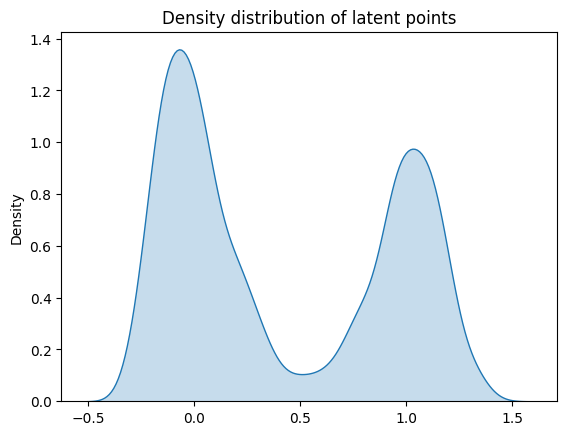

In [81]:
# project the data onto a 1 dimensional line
line_between_clusters = centroids.values[1] - centroids.values[0]
relative_distances = np.dot((latent_cols - centroids.values[0]), line_between_clusters) / np.dot(line_between_clusters, line_between_clusters)
#projected_points = pd.DataFrame(centroids.values[0] + relative_distances[:, np.newaxis] * line_between_clusters)
#projected_points['ad_label'] = latent_space['ad_label']
# plot density distribution of points projected onto a single line
sns.kdeplot(relative_distances, fill=True, bw_adjust=0.5)
plt.title('Density distribution of latent points')

In [82]:
# sampling equidistant points across projected line
relative_samples = np.linspace(np.min(relative_distances), np.max(relative_distances), num_samples)
projected_samples = centroids.values[0] + relative_samples[:, np.newaxis] * line_between_clusters
projected_samples.shape

(40, 8)

Predict labels of samples

In [83]:
# relative distances, relative samples
predicted_labels = []
for sample in relative_samples:
    closest_inds = np.argsort(np.abs(relative_distances - sample))[:label_count]
    predicted_labels.append((latent_space.iloc[closest_inds, -1]).mode()[0])
#predicted_labels

Decode samples

In [84]:
projected_samples.shape

(40, 8)

In [85]:
projected_tensor = torch.tensor(projected_samples, dtype=torch.float32).to(device)
label_tensor = torch.tensor(predicted_labels, dtype=torch.long).to(device)
recon_standardized = vae.decode(projected_tensor, label_tensor)
recon = recon_standardized * col_std + col_means

In [86]:
sampled_reconstructions = pd.DataFrame(recon.detach().cpu().numpy(), columns=columns_ordered)
sampled_reconstructions['ad_labels'] = predicted_labels
sampled_reconstructions

,Activity/waking min,Latency (min),Sleep/L (min),Sleep/D (min),Bout number/L,Bout number/D,Average bout length/L,Average bout length/D,Total activity/L,Total activity/D,Activity/waking min/L,Activity/waking min /D,Morning Anticipation,Evening Anticipation,Morning Anticipation phase,Evening Anticipation phase,ad_labels
0,2.331835,78.115768,190.503067,367.976440,10.949836,18.230503,20.316555,10.621490,1095.111206,835.017395,0.892304,0.798217,-0.037624,0.123478,21.232708,9.121264,0
1,2.274998,73.158211,222.762924,395.494202,11.632494,17.312445,21.638172,20.239227,1011.567505,765.299255,0.836398,0.739151,-0.028360,0.137475,21.233400,9.204357,0
2,2.244032,67.460426,260.095032,431.040222,12.302629,16.246166,23.337919,27.737141,925.161377,684.472107,0.780783,0.674560,-0.016896,0.157095,21.250408,9.310746,0
3,2.233046,61.256248,300.650513,472.072266,12.965611,15.071875,25.273544,33.875992,838.406311,596.444824,0.726604,0.606559,-0.003706,0.180390,21.280266,9.432739,0
4,2.226987,54.988449,340.780457,513.338318,13.636209,13.867794,27.158974,40.395897,755.174561,508.617401,0.675160,0.538732,0.010270,0.203314,21.314922,9.554026,0
5,2.210044,49.111191,376.784424,549.526550,14.327060,12.714407,28.707939,49.034889,679.138245,428.413757,0.627539,0.474646,0.024022,0.221803,21.345732,9.658134,0
6,2.174296,43.888172,406.689880,577.975464,15.036440,11.657704,29.780687,60.523373,612.219177,359.740509,0.584279,0.416314,0.036872,0.233909,21.367619,9.737046,0
7,2.120522,39.373146,430.394775,598.931885,15.745410,10.704834,30.397873,74.489822,554.514648,302.623352,0.545384,0.364022,0.048536,0.239997,21.379641,9.791893,0
8,2.053538,35.517052,448.674988,614.105103,16.421591,9.842439,30.662148,89.997971,505.237396,255.055328,0.510564,0.317085,0.058952,0.241606,21.383049,9.828141,0
9,1.978030,32.264931,462.296143,625.361084,17.022877,9.053408,30.687702,106.029831,463.556091,214.675140,0.479459,0.274546,0.068103,0.240423,21.379519,9.851304,0


In [87]:
np.min(original_data['Average bout length/L']), np.max(original_data['Average bout length/L'])

(5.588235294117647, 140.375)

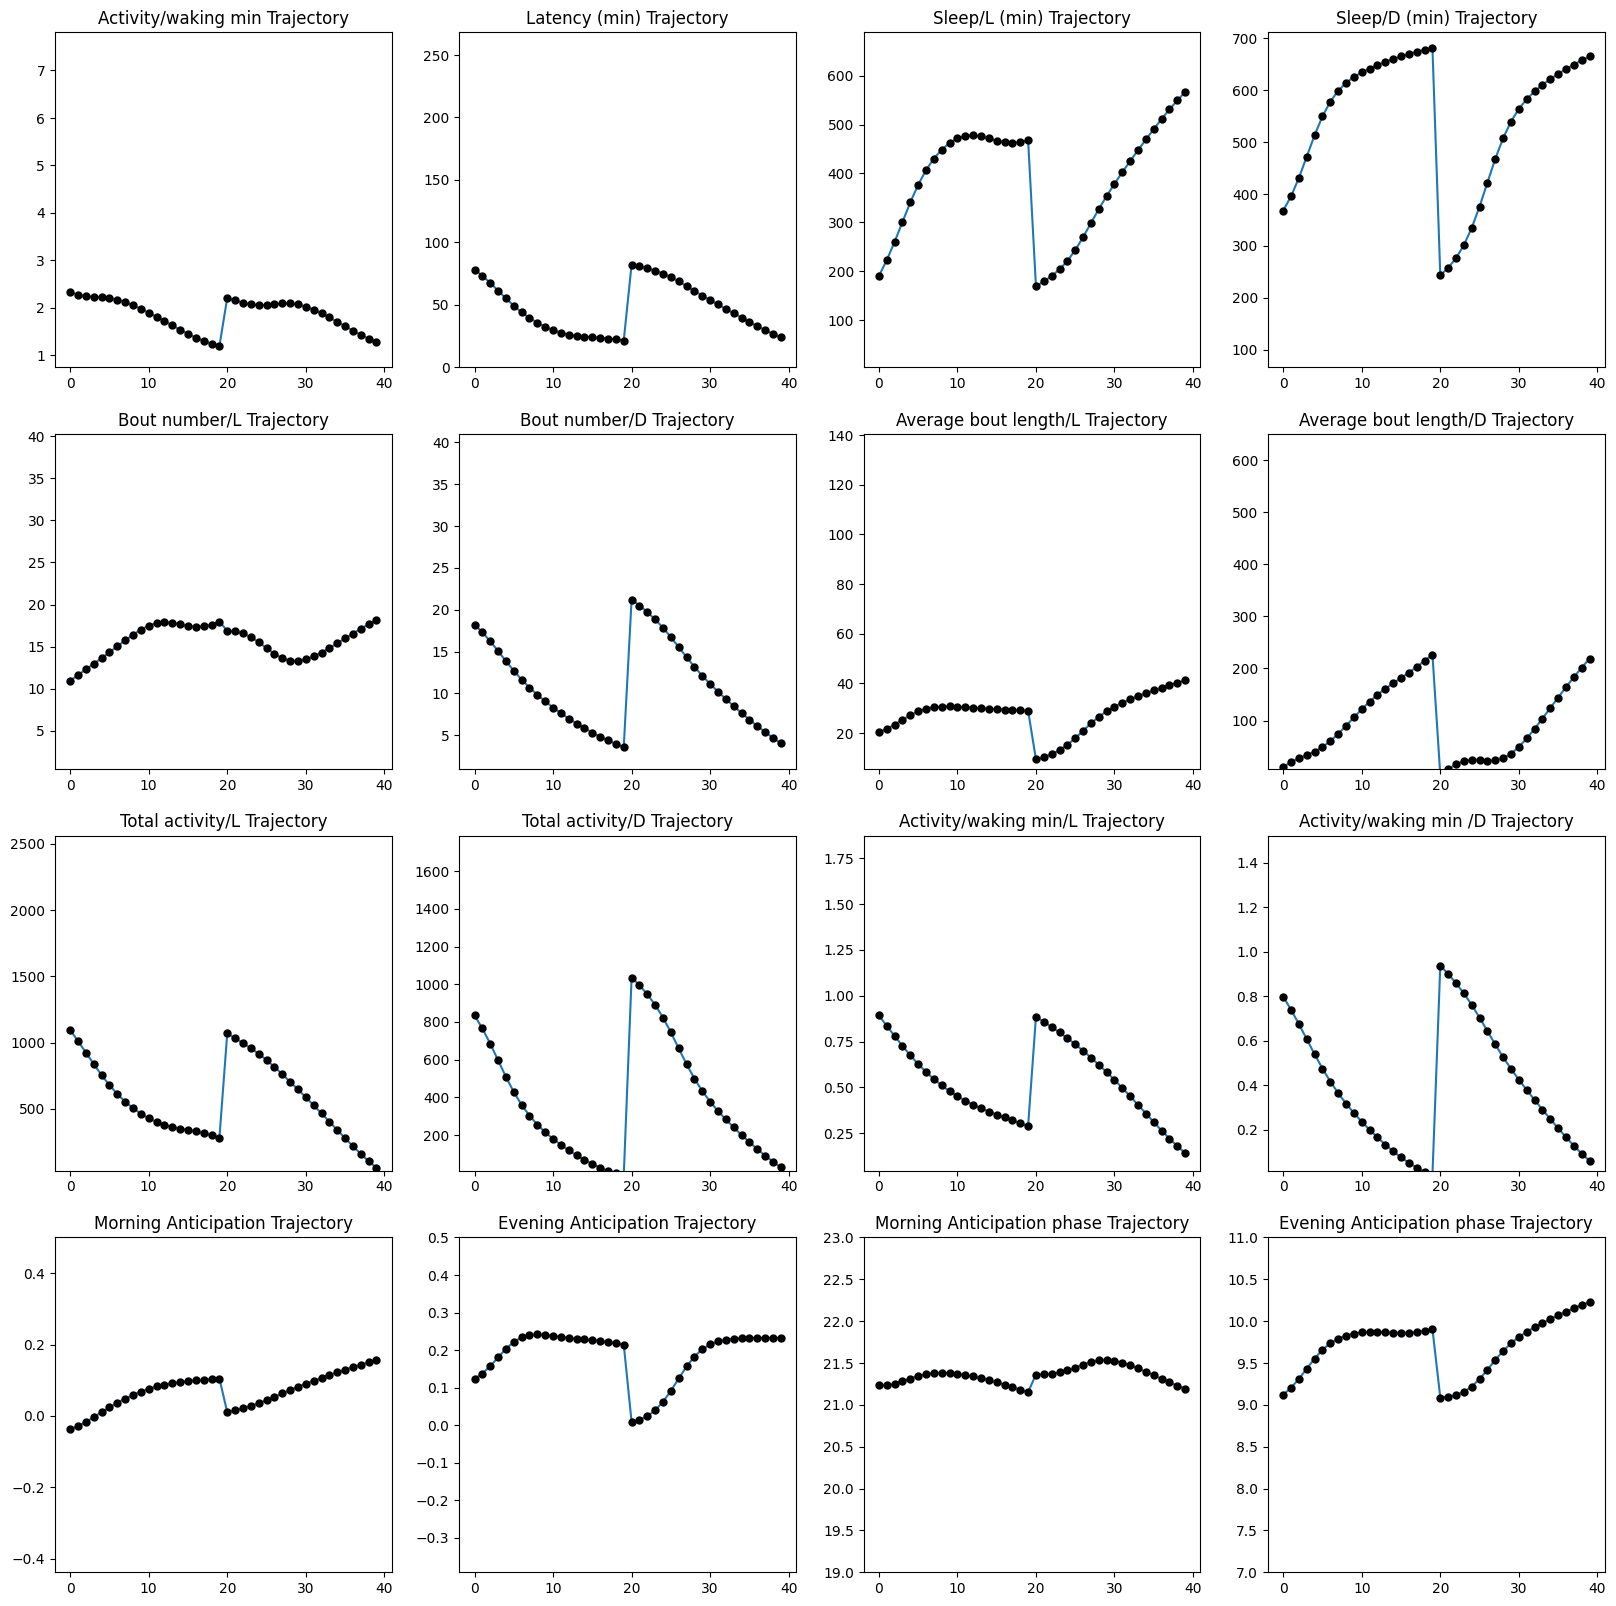

In [164]:
fig, ax = plt.subplots(4, 4, figsize=(20, 20))
for col, ax in zip(sampled_reconstructions.columns, ax.flatten()):
    ax.plot(sampled_reconstructions[col])
    ax.plot(sampled_reconstructions[col], 'ko', markersize=5)
    ax.set_ylim(np.min(original_data[col]), np.max(original_data[col]))
    ax.set_title(col + ' Trajectory')

Text(0.5, 1.0, 'Average Bout Length Trajectory')

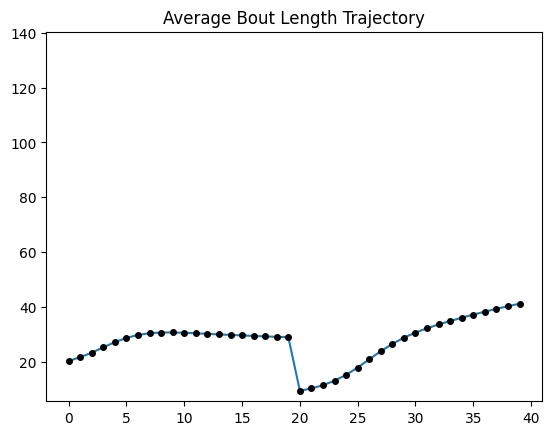

In [88]:
plt.plot(sampled_reconstructions['Average bout length/L'])
plt.plot(sampled_reconstructions['Average bout length/L'], 'ko', markersize=4)
plt.ylim(np.min(original_data['Average bout length/L']), np.max(original_data['Average bout length/L']))
plt.title('Average Bout Length Trajectory')

Text(0.5, 1.0, 'Sleep/L Trajectory')

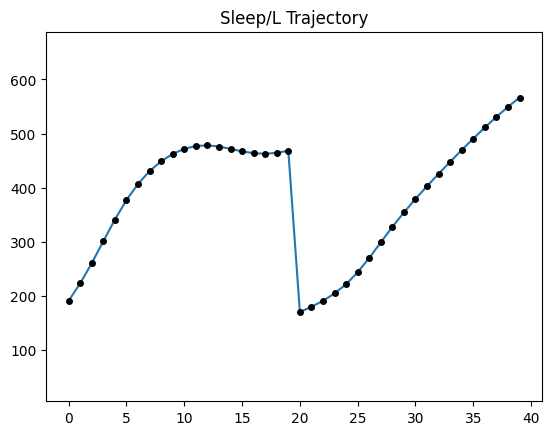

In [89]:
plt.plot(sampled_reconstructions['Sleep/L (min)'])
plt.plot(sampled_reconstructions['Sleep/L (min)'], 'ko', markersize=4)
plt.ylim(np.min(original_data['Sleep/L (min)']), np.max(original_data['Sleep/L (min)']))
plt.title('Sleep/L Trajectory')

Text(0.5, 1.0, 'Bout Number Trajectory')

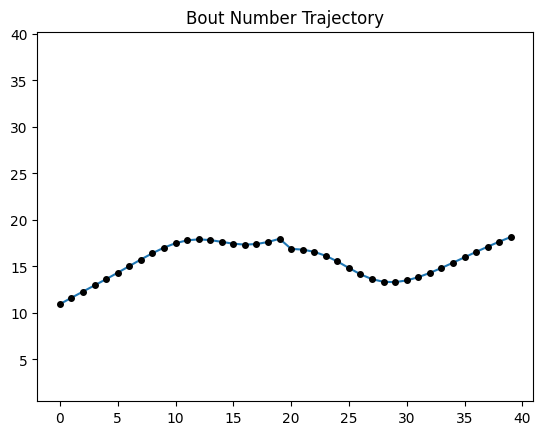

In [90]:
plt.plot(sampled_reconstructions['Bout number/L'])
plt.plot(sampled_reconstructions['Bout number/L'], 'ko', markersize=4)
plt.ylim(np.min(original_data['Bout number/L']), np.max(original_data['Bout number/L']))
plt.title('Bout Number Trajectory')

Text(0.5, 1.0, 'Morning anticipation Trajectory')

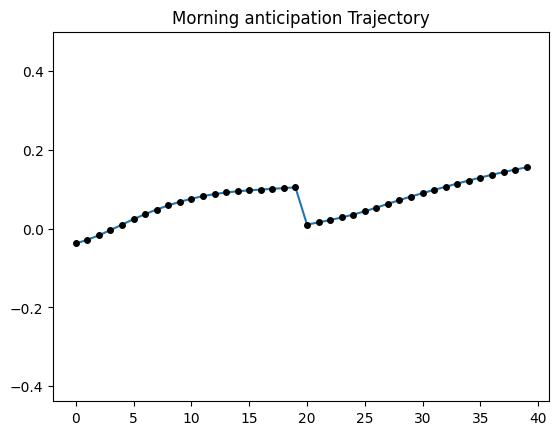

In [91]:
plt.plot(sampled_reconstructions['Morning Anticipation'])
plt.plot(sampled_reconstructions['Morning Anticipation'], 'ko', markersize=4)
plt.ylim(np.min(original_data['Morning Anticipation']), np.max(original_data['Morning Anticipation']))
plt.title('Morning anticipation Trajectory')

Text(0.5, 1.0, 'Activity/waking min Trajectory')

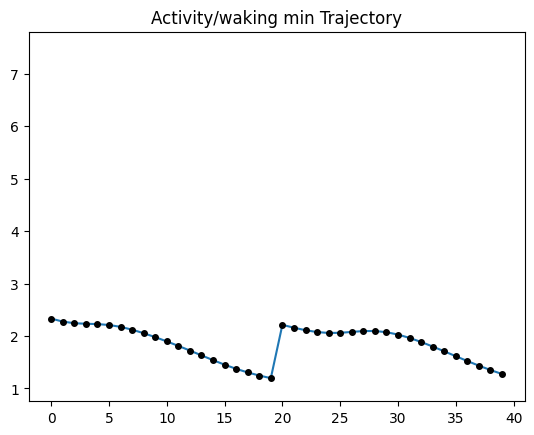

In [137]:
plt.plot(sampled_reconstructions['Activity/waking min'])
plt.plot(sampled_reconstructions['Activity/waking min'], 'ko', markersize=4)
plt.ylim(np.min(original_data['Activity/waking min']), np.max(original_data['Activity/waking min']))
plt.title('Activity/waking min Trajectory')

Latent trajectory analysis with density guided interpolation
- This trajectory analysis with sample sequentially but in higher density regions in order to gain a smoother interpolation through the latent space

In [93]:
from scipy.stats import gaussian_kde

<Axes: ylabel='Density'>

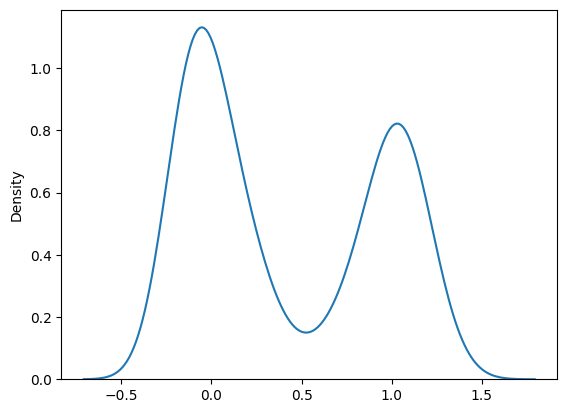

In [94]:
sns.kdeplot(relative_distances)

In [95]:
# line_between_clusters 
# relative_distances identifies the distance of each point on the line relative to one cluster (cluster 0 in this case)
kde = gaussian_kde(relative_distances)

In [96]:
density_val_0 = kde(0)[0]
density_val_05 = kde(0.5)[0]
density_val_0, density_val_05, kde(1)[0]

(1.0913492771187492, 0.15276617899283199, 0.8118318830538926)

In [97]:
density_guided_samples = []
step_size = (np.max(relative_distances) - np.min(relative_distances)) / max_samples
current_sample = np.min(relative_distances)
while len(density_guided_samples) < max_samples and current_sample < np.max(relative_distances): 
    if kde(current_sample)[0] > kde_sampling_threshold:
        density_guided_samples.append(current_sample)
        #print(kde(current_sample)[0])
    current_sample += step_size

In [98]:
projected_samples_dg = centroids.values[0] + np.array(density_guided_samples)[:, np.newaxis] * line_between_clusters
projected_samples_dg.shape

(61, 8)

Predict labels of density guided samples

In [99]:
# density guided samples, relative samples
predicted_labels_dg = []
for sample in density_guided_samples:
    closest_inds = np.argsort(np.abs(relative_distances - sample))[:label_count]
    predicted_labels_dg.append((latent_space.iloc[closest_inds, -1]).mode()[0])
predicted_labels_dg

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

In [139]:
projected_tensor_dg = torch.tensor(projected_samples_dg, dtype=torch.float32).to(device)
label_tensor_dg = torch.tensor(predicted_labels_dg, dtype=torch.long).to(device)
recon_standardized_dg = vae.decode(projected_tensor_dg, label_tensor_dg)
recon_dg = recon_standardized_dg * col_std + col_means

In [140]:
sampled_reconstructions_dg = pd.DataFrame(recon_dg.detach().cpu().numpy(), columns=columns_ordered)
sampled_reconstructions_dg['ad_labels'] = predicted_labels_dg
sampled_reconstructions_dg

,Activity/waking min,Latency (min),Sleep/L (min),Sleep/D (min),Bout number/L,Bout number/D,Average bout length/L,Average bout length/D,Total activity/L,Total activity/D,Activity/waking min/L,Activity/waking min /D,Morning Anticipation,Evening Anticipation,Morning Anticipation phase,Evening Anticipation phase,ad_labels
0,2.285289,74.315643,215.208221,388.726685,11.483334,17.527645,21.313404,18.308578,1030.247192,781.643921,0.848707,0.752658,-0.030593,0.133895,21.231833,9.184011,0
1,2.267931,72.238602,228.774475,400.998535,11.747309,17.141115,21.902121,21.657734,997.033203,752.289429,0.826894,0.728526,-0.026561,0.140435,21.235167,9.220877,0
2,2.254589,70.049606,243.111237,414.496338,12.009255,16.732090,22.548437,24.678596,963.411865,721.254517,0.805150,0.703568,-0.022194,0.147834,21.241009,9.261312,0
3,2.245012,67.760315,258.127747,429.097961,12.269392,16.302565,23.245438,27.405781,929.517578,688.734436,0.783540,0.677896,-0.017516,0.156000,21.249203,9.304951,0
4,2.238672,65.388702,273.678925,444.599457,12.528227,15.855667,23.981840,29.903690,895.527710,655.030151,0.762137,0.651664,-0.012565,0.164775,21.259451,9.351166,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,1.750287,41.190010,459.546509,616.274536,15.139603,8.040971,35.518955,114.611465,369.827942,218.422012,0.379126,0.267144,0.118601,0.231033,21.414820,10.003415,1
57,1.714255,39.825024,468.000885,620.459778,15.363391,7.722857,35.977623,122.525284,345.370636,202.962372,0.360686,0.250585,0.121602,0.231460,21.398643,10.021647,1
58,1.677919,38.468021,476.373352,624.489685,15.589489,7.408803,36.427689,130.446945,320.982208,187.756470,0.342274,0.234188,0.124567,0.231776,21.382191,10.039557,1
59,1.641464,37.121792,484.654602,628.385132,15.816740,7.099000,36.869633,138.350388,296.723877,172.802811,0.323942,0.217976,0.127493,0.232003,21.365562,10.057165,1


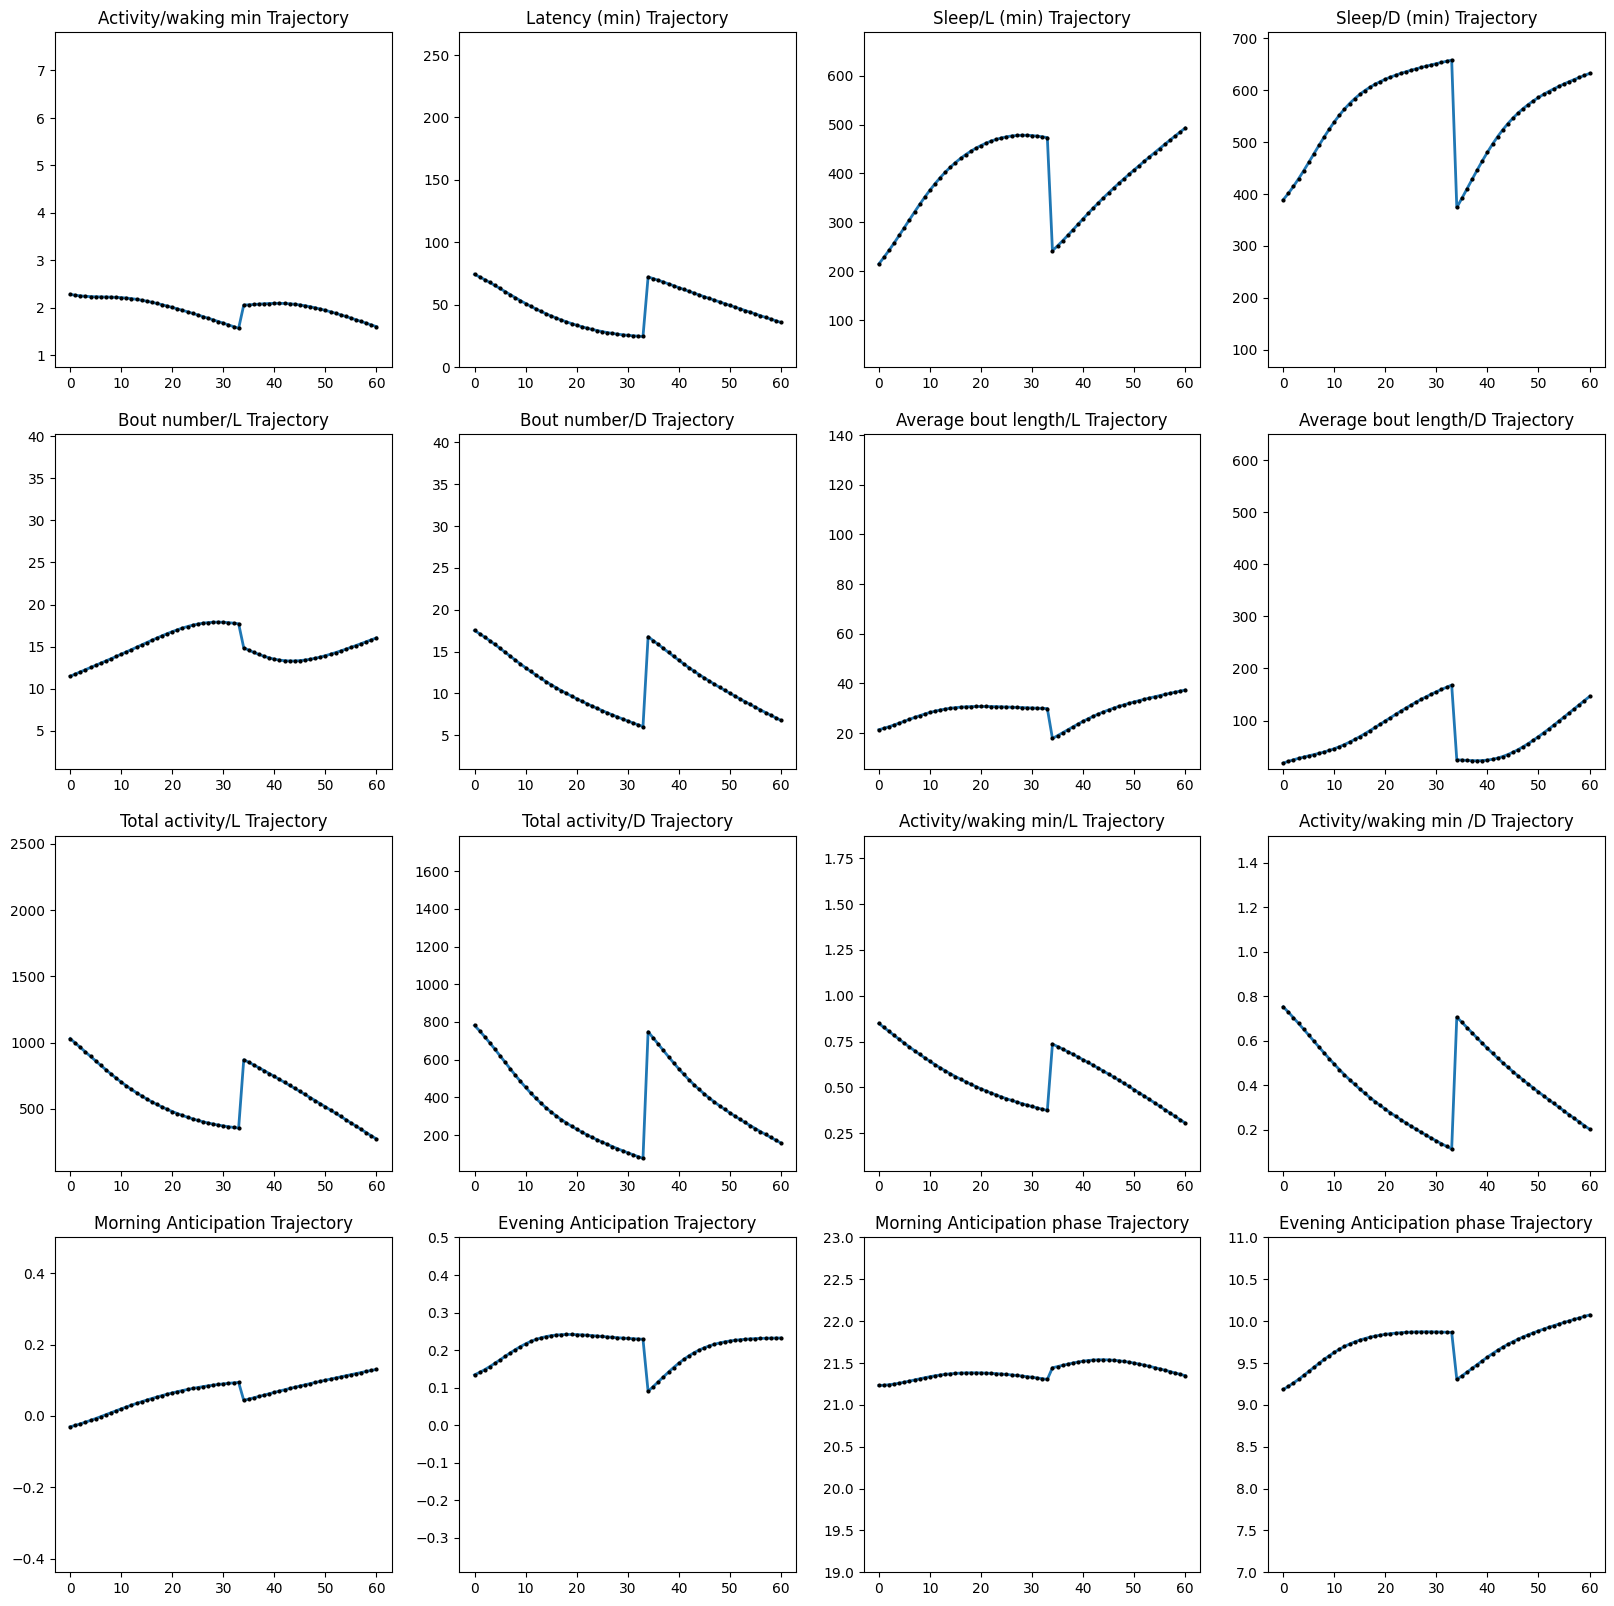

In [176]:
fig, ax = plt.subplots(4, 4, figsize=(20, 20))
for col, ax in zip(sampled_reconstructions_dg.columns, ax.flatten()):
    ax.plot(sampled_reconstructions_dg[col], linewidth=2)
    ax.plot(sampled_reconstructions_dg[col], 'ko', markersize=2)
    ax.set_ylim(np.min(original_data[col]), np.max(original_data[col]))
    ax.set_title(col + ' Trajectory')

Text(0.5, 1.0, 'Average Bout Length Trajectory')

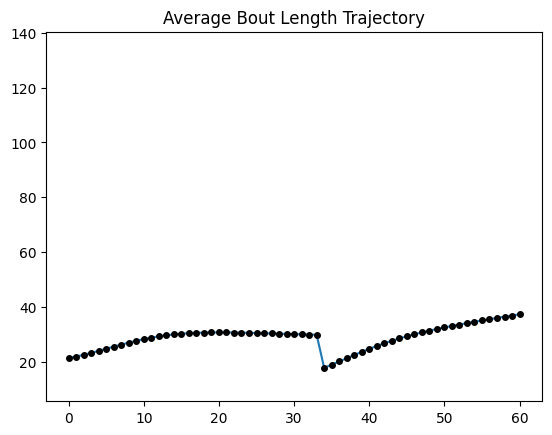

In [141]:
plt.plot(sampled_reconstructions_dg['Average bout length/L'])
plt.plot(sampled_reconstructions_dg['Average bout length/L'], 'ko', markersize=4)
plt.ylim(np.min(original_data['Average bout length/L']), np.max(original_data['Average bout length/L']))
plt.title('Average Bout Length Trajectory')

Text(0.5, 1.0, 'Sleep/L Trajectory')

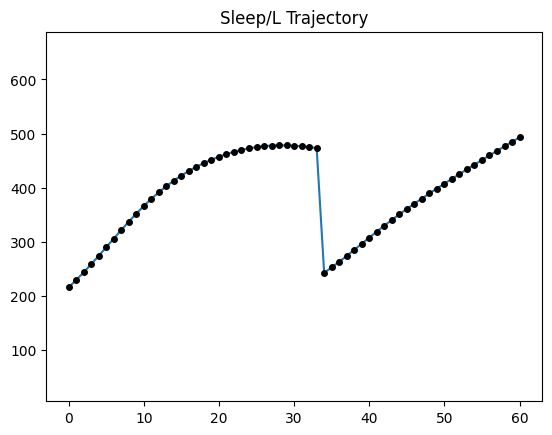

In [145]:
plt.plot(sampled_reconstructions_dg['Sleep/L (min)'])
plt.plot(sampled_reconstructions_dg['Sleep/L (min)'], 'ko', markersize=4)
plt.ylim(np.min(original_data['Sleep/L (min)']), np.max(original_data['Sleep/L (min)']))
plt.title('Sleep/L Trajectory')

Text(0.5, 1.0, 'Bout Number Trajectory')

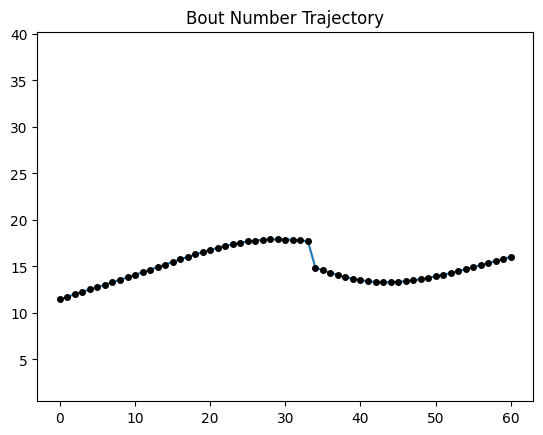

In [146]:
plt.plot(sampled_reconstructions_dg['Bout number/L'])
plt.plot(sampled_reconstructions_dg['Bout number/L'], 'ko', markersize=4)
plt.ylim(np.min(original_data['Bout number/L']), np.max(original_data['Bout number/L']))
plt.title('Bout Number Trajectory')

Text(0.5, 1.0, 'Morning Anticipation Trajectory')

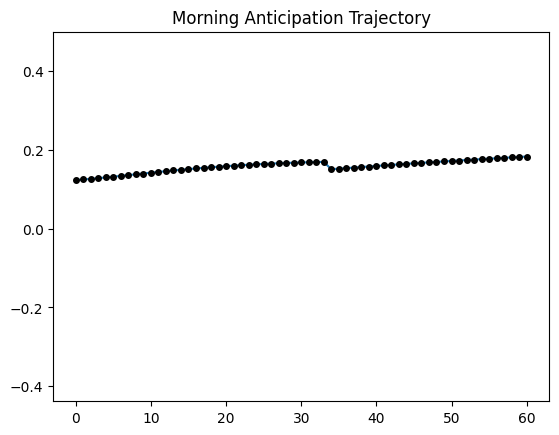

In [105]:
plt.plot(sampled_reconstructions_dg['Morning Anticipation'])
plt.plot(sampled_reconstructions_dg['Morning Anticipation'], 'ko', markersize=4)
plt.ylim(np.min(original_data['Morning Anticipation']), np.max(original_data['Morning Anticipation']))
plt.title('Morning Anticipation Trajectory')

Density guided interpolation (looking at the density gradient instead of density magnitude)

In [106]:
def get_density_gradient(sample, kde, epsilon=1e-4): 
    density_plus = kde(sample+epsilon)[0]
    density_minus = kde(sample-epsilon)[0]
    grad = (density_plus - density_minus) / (2.0 * epsilon)
    return grad

- Calculating the range of density gradients for deciding threshold 

In [107]:
density_gradients = []
for sample in relative_distances: 
    density_grad = get_density_gradient(sample, kde, 1e-4)
    density_gradients.append(density_grad)

In [108]:
len(density_gradients), np.min(density_gradients), np.max(density_gradients)

(1340, -2.7818675959240258, 3.9993192342491213)

In [109]:
densitygrad_guided_samples = []
step_size = (np.max(relative_distances) - np.min(relative_distances)) / max_samples
current_sample = np.min(relative_distances)
while len(densitygrad_guided_samples) < max_samples and current_sample < np.max(relative_distances): 
    if get_density_gradient(current_sample, kde, 1e-4) > kde_gradient_sampling_threshold:
        densitygrad_guided_samples.append(current_sample)
        #print(kde(current_sample)[0])
    current_sample += step_size

In [110]:
densitygrad_guided_samples

[-0.3359816332125324,
 -0.31840854748032116,
 -0.30083546174810993,
 -0.2832623760158987,
 -0.2656892902836875,
 -0.2481162045514763,
 -0.2305431188192651,
 -0.2129700330870539,
 -0.1953969473548427,
 -0.1778238616226315,
 -0.1602507758904203,
 -0.1426776901582091,
 -0.1251046044259979,
 -0.10753151869378672,
 -0.08995843296157552,
 -0.07238534722936432,
 0.5953919105946615,
 0.6129649963268726,
 0.6305380820590838,
 0.648111167791295,
 0.6656842535235061,
 0.6832573392557173,
 0.7008304249879285,
 0.7184035107201396,
 0.7359765964523508,
 0.753549682184562,
 0.7711227679167731,
 0.7886958536489843,
 0.8062689393811955,
 0.8238420251134067,
 0.8414151108456178,
 0.858988196577829,
 0.8765612823100402,
 0.8941343680422513,
 0.9117074537744625,
 0.9292805395066737,
 0.9468536252388848,
 0.964426710971096,
 0.9819997967033072,
 0.9995728824355183]

In [111]:
projected_samples_dgg = centroids.values[0] + np.array(densitygrad_guided_samples)[:, np.newaxis] * line_between_clusters
projected_samples_dgg.shape

(40, 8)

In [112]:
# density gradient guided samples, relative samples
predicted_labels_dgg = []
for sample in densitygrad_guided_samples:
    closest_inds = np.argsort(np.abs(relative_distances - sample))[:label_count]
    predicted_labels_dgg.append((latent_space.iloc[closest_inds, -1]).mode()[0])
predicted_labels_dgg

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

In [147]:
projected_tensor_dgg = torch.tensor(projected_samples_dgg, dtype=torch.float32).to(device)
label_tensor_dgg = torch.tensor(predicted_labels_dgg, dtype=torch.long).to(device)
recon_standardized_dgg = vae.decode(projected_tensor_dgg, label_tensor_dgg)
recon_dgg = recon_standardized_dgg * col_std + col_means

In [148]:
sampled_reconstructions_dgg = pd.DataFrame(recon_dgg.detach().cpu().numpy(), columns=columns_ordered)
sampled_reconstructions_dgg['ad_labels'] = predicted_labels_dgg
sampled_reconstructions_dgg

,Activity/waking min,Latency (min),Sleep/L (min),Sleep/D (min),Bout number/L,Bout number/D,Average bout length/L,Average bout length/D,Total activity/L,Total activity/D,Activity/waking min/L,Activity/waking min /D,Morning Anticipation,Evening Anticipation,Morning Anticipation phase,Evening Anticipation phase,ad_labels
0,2.331835,78.115768,190.503067,367.976440,10.949836,18.230503,20.316555,10.621490,1095.111206,835.017395,0.892304,0.798217,-0.037624,0.123478,21.232708,9.121264,0
1,2.306662,76.274948,202.452209,377.725769,11.217408,17.890776,20.785099,14.624359,1062.959717,809.223572,0.870528,0.775899,-0.034281,0.128249,21.231039,9.150835,0
2,2.285289,74.315643,215.208221,388.726685,11.483334,17.527645,21.313404,18.308578,1030.247192,781.643921,0.848707,0.752658,-0.030593,0.133895,21.231833,9.184011,0
3,2.267931,72.238602,228.774475,400.998535,11.747309,17.141115,21.902121,21.657734,997.033203,752.289429,0.826894,0.728526,-0.026561,0.140435,21.235167,9.220877,0
4,2.254589,70.049606,243.111237,414.496338,12.009255,16.732090,22.548437,24.678596,963.411865,721.254517,0.805150,0.703568,-0.022194,0.147834,21.241009,9.261312,0
5,2.245012,67.760315,258.127747,429.097961,12.269392,16.302565,23.245438,27.405781,929.517578,688.734436,0.783540,0.677896,-0.017516,0.156000,21.249203,9.304951,0
6,2.238672,65.388702,273.678925,444.599457,12.528227,15.855667,23.981840,29.903690,895.527710,655.030151,0.762137,0.651664,-0.012565,0.164775,21.259451,9.351166,0
7,2.234794,62.958450,289.570496,460.721741,12.786558,15.395557,24.742390,32.264149,861.657410,620.539001,0.741017,0.625067,-0.007390,0.173945,21.271341,9.399096,0
8,2.232408,60.497620,305.570038,477.129700,13.045350,14.927209,25.508827,34.598850,828.150391,585.731079,0.720262,0.598332,-0.002050,0.183251,21.284357,9.447698,0
9,2.230448,58.036304,321.428436,493.462280,13.305639,14.455956,26.261604,37.028973,795.258667,551.108337,0.699948,0.571698,0.003391,0.192415,21.297932,9.495847,0


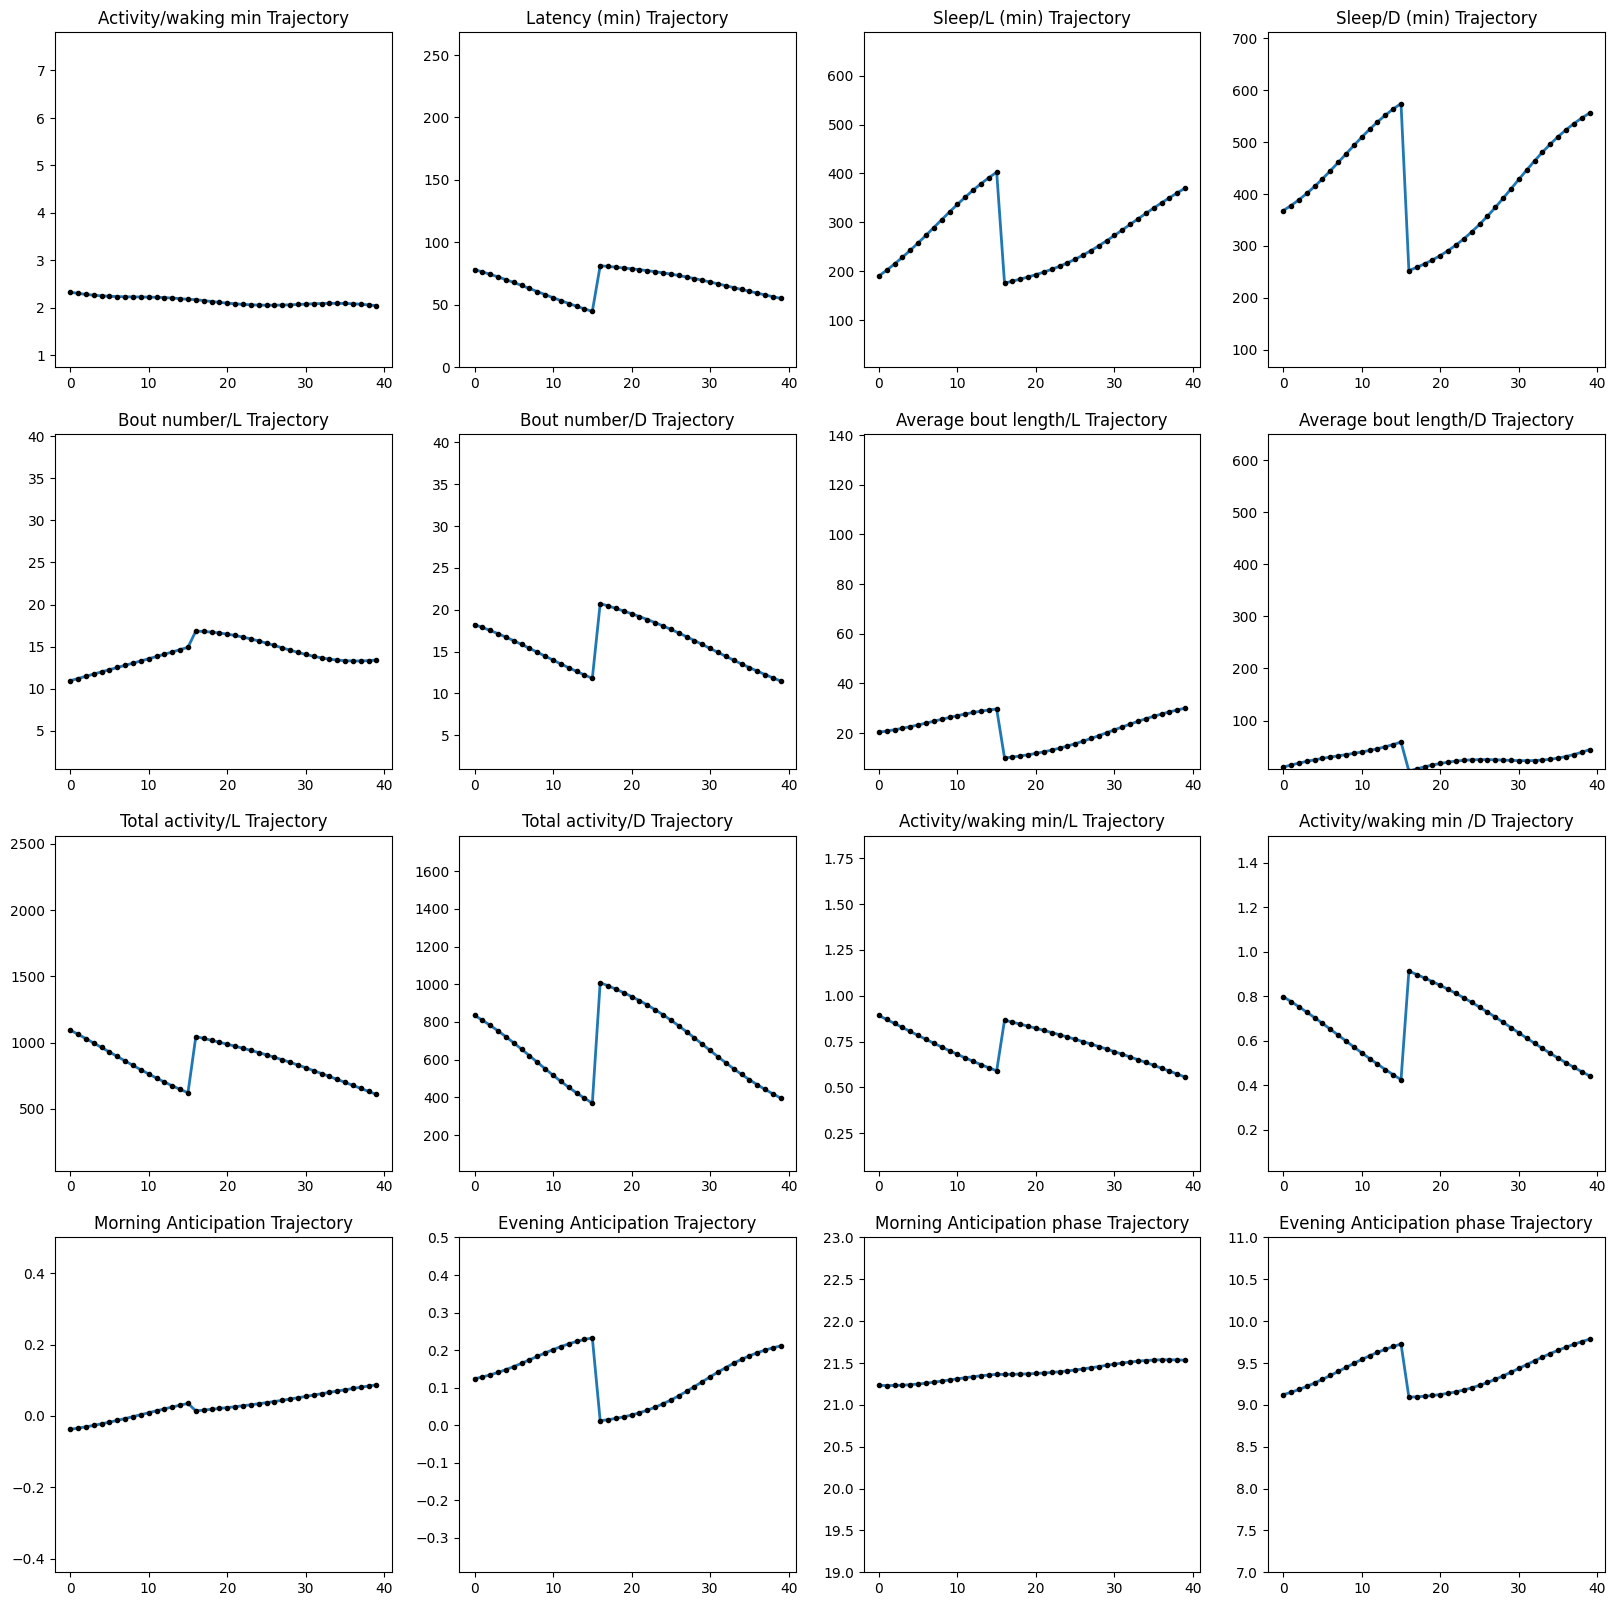

In [175]:
fig, ax = plt.subplots(4, 4, figsize=(20, 20))
for col, ax in zip(sampled_reconstructions_dgg.columns, ax.flatten()):
    ax.plot(sampled_reconstructions_dgg[col], linewidth=2)
    ax.plot(sampled_reconstructions_dgg[col], 'ko', markersize=3)
    ax.set_ylim(np.min(original_data[col]), np.max(original_data[col]))
    ax.set_title(col + ' Trajectory')

Text(0.5, 1.0, 'Average Bout Length Trajectory')

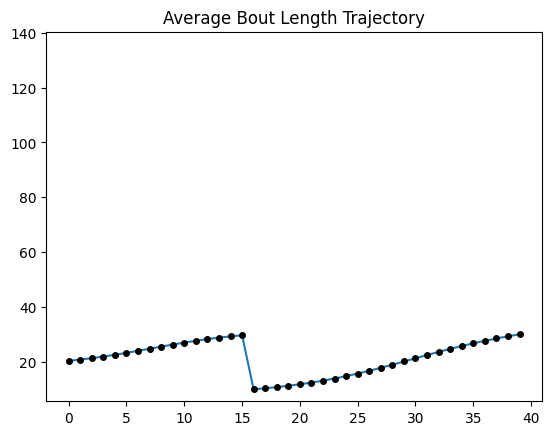

In [149]:
plt.plot(sampled_reconstructions_dgg['Average bout length/L'])
plt.plot(sampled_reconstructions_dgg['Average bout length/L'], 'ko', markersize=4)
plt.ylim(np.min(original_data['Average bout length/L']), np.max(original_data['Average bout length/L']))
plt.title('Average Bout Length Trajectory')

Text(0.5, 1.0, 'Sleep/L Trajectory')

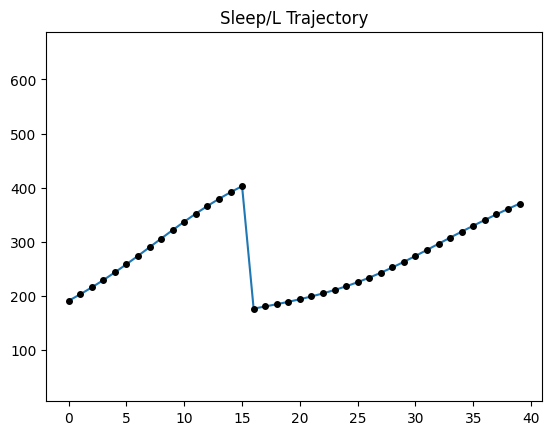

In [150]:
plt.plot(sampled_reconstructions_dgg['Sleep/L (min)'])
plt.plot(sampled_reconstructions_dgg['Sleep/L (min)'], 'ko', markersize=4)
plt.ylim(np.min(original_data['Sleep/L (min)']), np.max(original_data['Sleep/L (min)']))
plt.title('Sleep/L Trajectory')

Text(0.5, 1.0, 'Bout Number Trajectory')

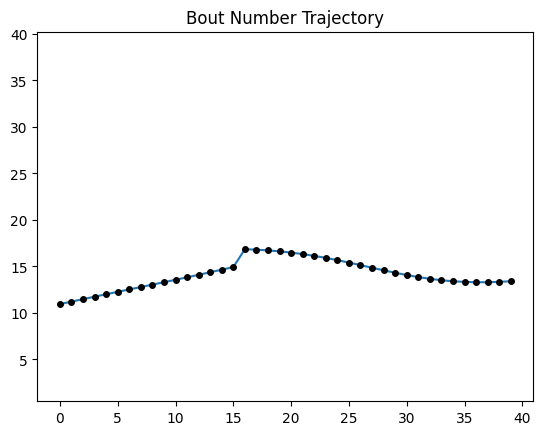

In [151]:
plt.plot(sampled_reconstructions_dgg['Bout number/L'])
plt.plot(sampled_reconstructions_dgg['Bout number/L'], 'ko', markersize=4)
plt.ylim(np.min(original_data['Bout number/L']), np.max(original_data['Bout number/L']))
plt.title('Bout Number Trajectory')

Text(0.5, 1.0, 'Morning Anticipation')

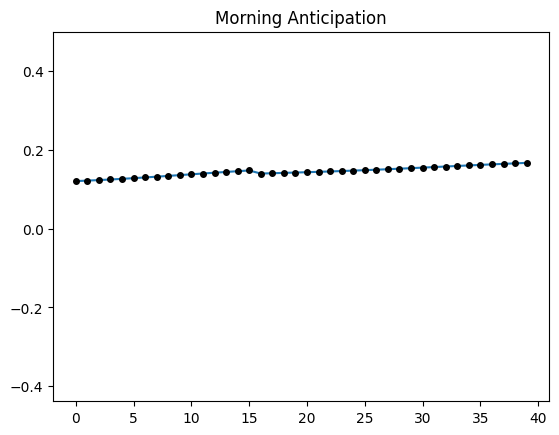

In [118]:
plt.plot(sampled_reconstructions_dgg['Morning Anticipation'])
plt.plot(sampled_reconstructions_dgg['Morning Anticipation'], 'ko', markersize=4)
plt.ylim(np.min(original_data['Morning Anticipation']), np.max(original_data['Morning Anticipation']))
plt.title('Morning Anticipation')

Text(0.5, 1.0, 'Activity/waking min')

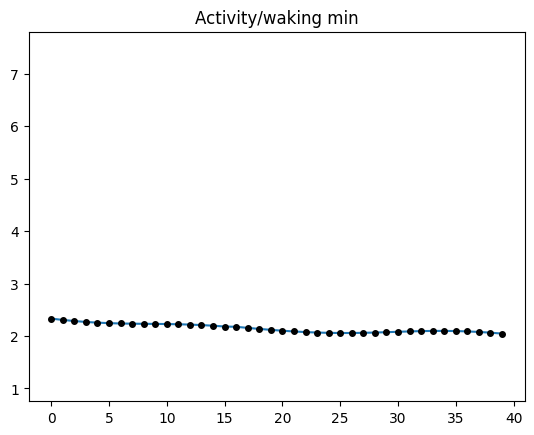

In [152]:
plt.plot(sampled_reconstructions_dgg['Activity/waking min'])
plt.plot(sampled_reconstructions_dgg['Activity/waking min'], 'ko', markersize=4)
plt.ylim(np.min(original_data['Activity/waking min']), np.max(original_data['Activity/waking min']))
plt.title('Activity/waking min')

Text(0.5, 1.0, 'Morning Anticipation phase')

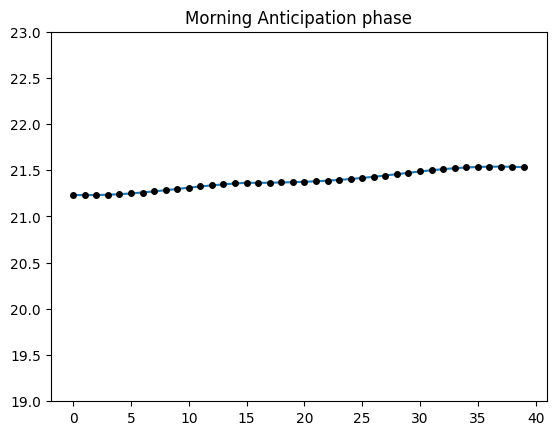

In [154]:
plt.plot(sampled_reconstructions_dgg['Morning Anticipation phase'])
plt.plot(sampled_reconstructions_dgg['Morning Anticipation phase'], 'ko', markersize=4)
plt.ylim(np.min(original_data['Morning Anticipation phase']), np.max(original_data['Morning Anticipation phase']))
plt.title('Morning Anticipation phase')